In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("insurance.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
# Converting categorical variables to numeric

df_encoded = pd.get_dummies(df, drop_first=True)


df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [5]:
# Defining predictors and target

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 8)
y shape: (1338,)


In [6]:
# Splitting the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (1070, 8)
Test size: (268, 8)


In [7]:
# Fitting regression tree & limiting the tree

from sklearn.tree import DecisionTreeRegressor
# Creating model & starting with a BIG tree (I want overfitting later)
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
# Trainning model
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


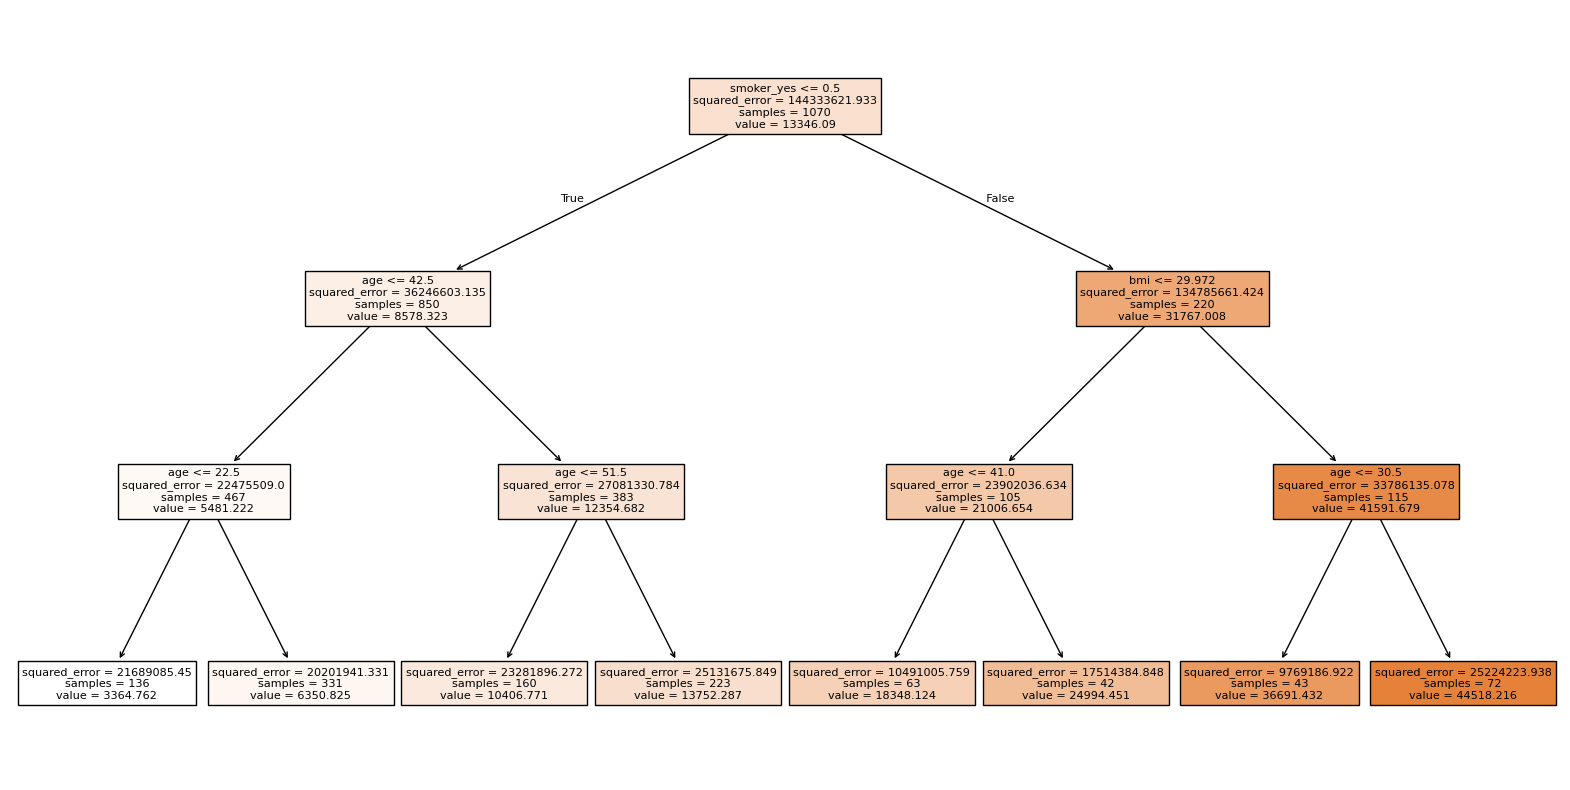

In [8]:
# Visualizing the tree

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_model, 
          feature_names=X.columns, 
          filled=True)

plt.show()

## How the Tree Partitions the Predictor Space

The regression tree partitions the predictor space using a series of binary splits based on the most important variables.

The first split is on **smoking status (`smoker_yes`)**, which separates smokers from non-smokers. This indicates that smoking has the strongest influence on medical charges.

Subsequent splits occur on variables such as **age** and **BMI**, further dividing the data into smaller and more homogeneous regions. For example, among non-smokers, the tree splits based on age groups, while among smokers, BMI and age further determine the cost levels.

Each terminal node represents a region in the predictor space where the model predicts the **average medical charges** of observations within that region. For instance, individuals who are smokers with high BMI values fall into regions with significantly higher predicted charges, while younger non-smokers fall into regions with lower predicted costs.

Overall, the tree creates distinct regions that group individuals with similar characteristics, allowing for **piecewise constant predictions** within each region.

In [9]:
# Comparing training vs test error

from sklearn.metrics import mean_squared_error

# Predictions
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

# Errors
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

Training MSE: 21120357.016202502
Test MSE: 22812669.852340844


### The regression tree model exhibits clear signs of overfitting. The training mean squared error is significantly lower than the test mean squared error, indicating that the model fits the training data very well but performs poorly on unseen data. This suggests that the tree has become too complex and is capturing noise rather than the underlying pattern.

# Refitting the FULL tree for pruning

In [10]:
# Refitting the FULL tree for pruning

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

print("Full tree depth:", full_tree.get_depth())
print("Full tree terminal nodes:", full_tree.get_n_leaves())

Full tree depth: 21
Full tree terminal nodes: 1068


In [11]:
# Computing pruning path from full tree

path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of alphas:", len(ccp_alphas))

Number of alphas: 921


# Cost-Complexity Pruning

In [12]:
# computing pruning path from the FULL tree

path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of alphas:", len(ccp_alphas))

Number of alphas: 921


In [13]:
# Trainning multiple trees
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append(model)

print("Number of trees trained:", len(trees))

Number of trees trained: 921


In [14]:
# creating train errors 

train_errors = []
test_errors = []

for model in trees:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

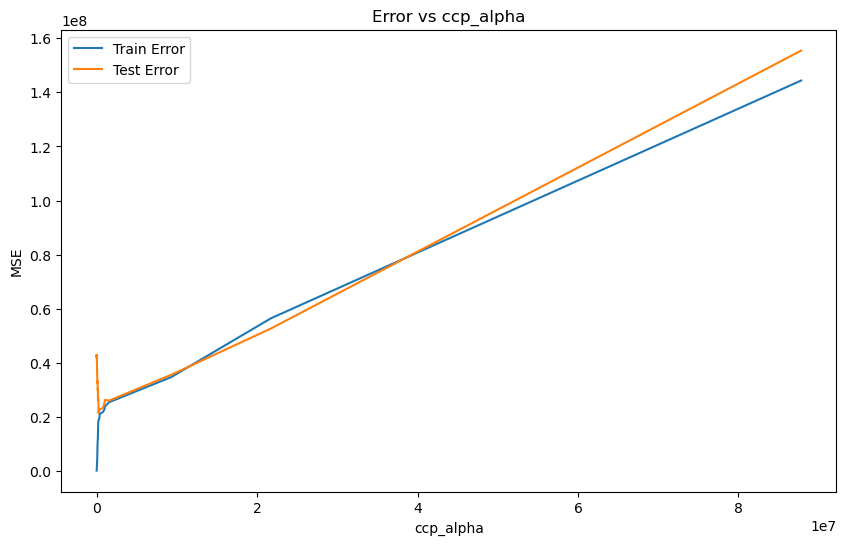

In [15]:
# plott

import numpy as np

ccp_alphas_np = np.array(ccp_alphas)
train_errors_np = np.array(train_errors)
test_errors_np = np.array(test_errors)

# Sort values (important!)
sorted_index = np.argsort(ccp_alphas_np)

ccp_alphas_sorted = ccp_alphas_np[sorted_index]
train_errors_sorted = train_errors_np[sorted_index]
test_errors_sorted = test_errors_np[sorted_index]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ccp_alphas_sorted, train_errors_sorted, label="Train Error")
plt.plot(ccp_alphas_sorted, test_errors_sorted, label="Test Error")

plt.xlabel("ccp_alpha")
plt.ylabel("MSE")
plt.legend()
plt.title("Error vs ccp_alpha")
plt.show()

In [16]:
# Find best alpha (minimum test error)

best_index = np.argmin(test_errors_sorted)
best_alpha = ccp_alphas_sorted[best_index]

print("Best ccp_alpha:", best_alpha)
print("Lowest Test MSE:", test_errors_sorted[best_index])

Best ccp_alpha: 244614.40401744086
Lowest Test MSE: 21438560.532222822


### The optimal value of the cost-complexity parameter (ccp_alpha) was found to be approximately 244,614, corresponding to the minimum test mean squared error of about 2,143,856. This indicates that a moderately pruned tree achieves the best balance between underfitting and overfitting

# Train Optimal Tree

In [17]:
# Train final pruned tree

optimal_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=244614.40401744086
)

optimal_tree.fit(X_train, y_train)

print("Optimal tree depth:", optimal_tree.get_depth())
print("Optimal number of terminal nodes:", optimal_tree.get_n_leaves())

Optimal tree depth: 6
Optimal number of terminal nodes: 14


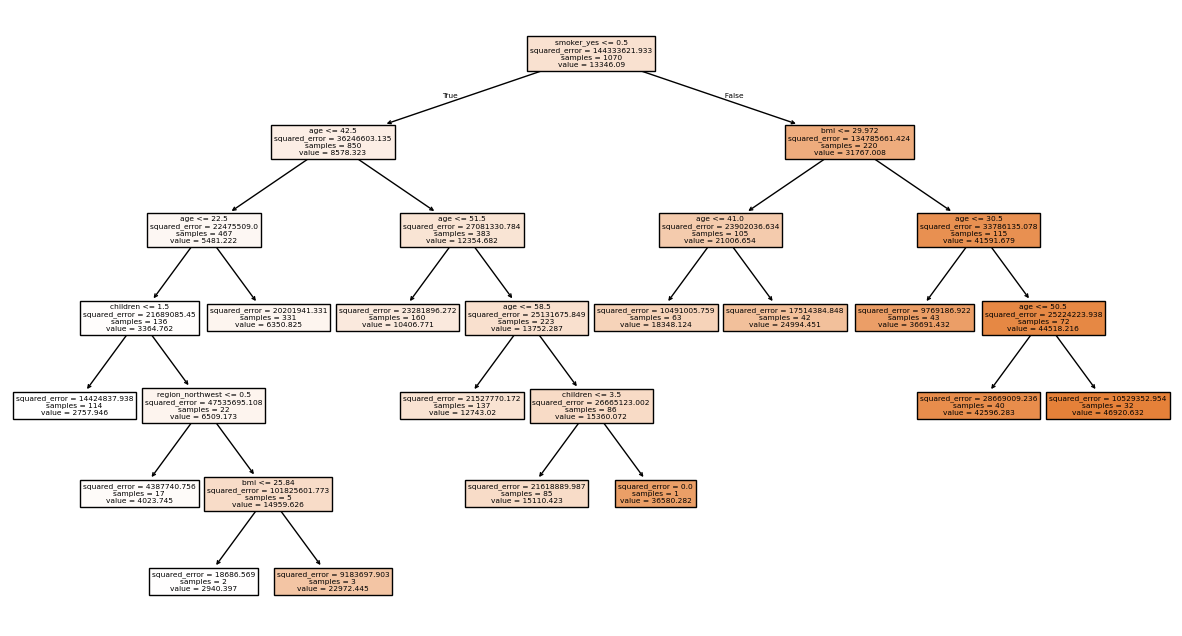

In [18]:
plt.figure(figsize=(15,8))
plot_tree(optimal_tree, 
          feature_names=X.columns, 
          filled=True)

plt.show()

### 1. Optimal number of terminal nodes
The optimal regression tree has 14 terminal nodes (leaves), which represents the best balance between model complexity and predictive performance.

### 2. Does pruning improve performance?
YES:

Pruning significantly improves model performance by reducing overfitting. The fully grown tree had a very low training error but a high test error, indicating overfitting. After applying cost-complexity pruning, the test error decreased substantially, showing that the pruned model generalizes better to unseen data.

### 3. Bias-Variance Trade-off

The fully grown tree exhibits low bias but high variance, as it fits the training data very closely but performs poorly on new data. Pruning increases the bias slightly but reduces the variance, leading to improved generalization. The optimal pruned tree achieves a better balance between bias and variance.

In [19]:
# Cross-validation for each pruned tree

from sklearn.model_selection import cross_val_score

cv_errors = []
terminal_nodes = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    
    cv_errors.append(-scores.mean())
    
    model.fit(X_train, y_train)
    terminal_nodes.append(model.get_n_leaves())

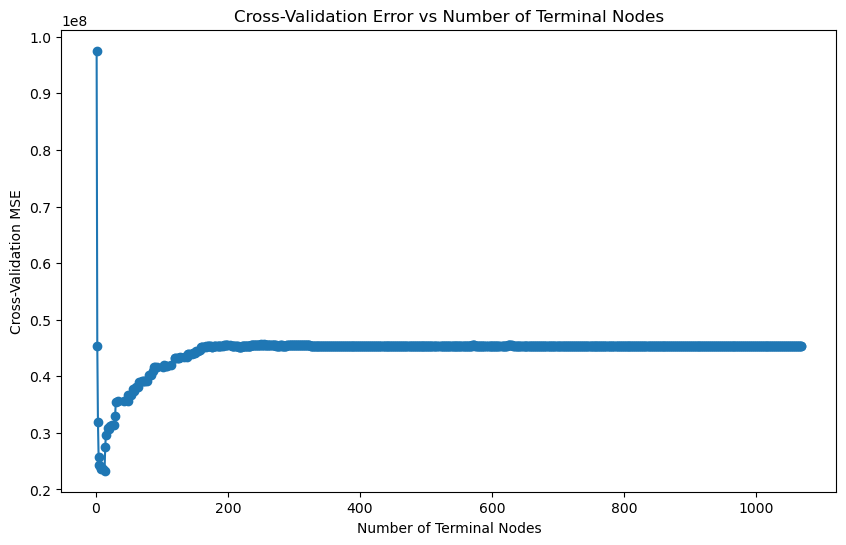

In [20]:
# Plot error vs number of terminal nodes

plt.figure(figsize=(10,6))
plt.plot(terminal_nodes, cv_errors, marker="o")
plt.xlabel("Number of Terminal Nodes")
plt.ylabel("Cross-Validation MSE")
plt.title("Cross-Validation Error vs Number of Terminal Nodes")
plt.show()

In [21]:
# Cell 21: Find optimal tree size using cross-validation

best_cv_index = np.argmin(cv_errors)

best_cv_alpha = ccp_alphas[best_cv_index]
best_cv_nodes = terminal_nodes[best_cv_index]
best_cv_error = cv_errors[best_cv_index]

print("Best CV alpha:", best_cv_alpha)
print("Optimal terminal nodes from CV:", best_cv_nodes)
print("Lowest CV MSE:", best_cv_error)

Best CV alpha: 310695.7566488406
Optimal terminal nodes from CV: 13
Lowest CV MSE: 23304297.243309703


### Based on 5-fold cross-validation, the optimal regression tree has 13 terminal nodes. This tree gives the lowest cross-validation MSE of about 23,304,297, showing the best balance between model complexity and prediction accuracy